# 🎬 Netflix Content Classification — AI & Big Data Final Project 2026

**Tujuan:** Memprediksi apakah konten Netflix adalah **Movie** atau **TV Show** berdasarkan fitur-fitur seperti rating, durasi, genre, tahun rilis, dan negara.

**Dataset:** Netflix Titles (8807 baris × 12 kolom)

**Algoritma:** Random Forest Classifier vs Logistic Regression

---
**Langkah-langkah:**
1. Persiapan Data & EDA
2. Training & Testing Model
3. Evaluasi Model


## 📦 Install & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


---
# STEP 1: Persiapan Data & EDA
## 1.1 Load Dataset

In [2]:
from google.colab import files
import pandas as pd
import io

print('📂 Upload file netflix_titles.csv:')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ Dataset berhasil diload!')
print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris  : {df.shape[0]}')
print(f'📋 Jumlah kolom  : {df.shape[1]}')
df.head()

📂 Upload file netflix_titles.csv:


Saving netflix_titles.csv to netflix_titles.csv

✅ Dataset berhasil diload!
📊 Shape dataset: (8807, 12)
📋 Jumlah baris  : 8807
📋 Jumlah kolom  : 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:

df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 1.2 Pengecekan & Penanganan Missing Values

🔍 Kolom dengan Missing Values:
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


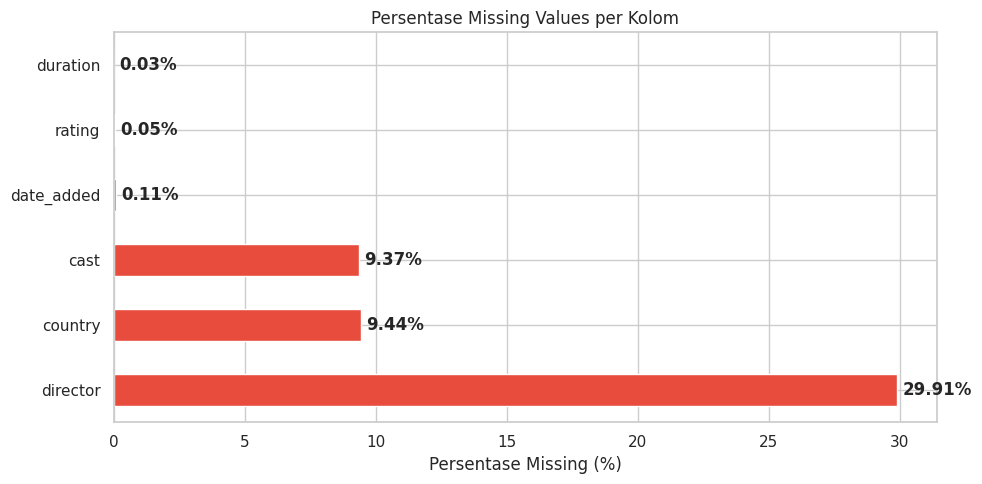

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('🔍 Kolom dengan Missing Values:')
print(missing_df)


fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
df_clean = df.copy()

# 1. Kolom 'director' - missing 29%, tidak dipakai sebagai fitur → drop kolom
df_clean.drop(columns=['director'], inplace=True)
print('✅ Kolom director di-drop (missing 29%)')

# 2. Kolom 'cast' - missing 9%, tidak dipakai sebagai fitur → drop kolom
df_clean.drop(columns=['cast'], inplace=True)
print('✅ Kolom cast di-drop (tidak digunakan sebagai fitur)')

# 3. Kolom 'country' - isi missing dengan 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')
print('✅ Missing country diisi dengan "Unknown"')

# 4. Kolom 'date_added' - isi missing dengan 'Unknown'
df_clean['date_added'] = df_clean['date_added'].fillna('Unknown')
print('✅ Missing date_added diisi dengan "Unknown"')

# 5. Kolom 'rating' - 4 baris. Cek dulu
print('\nBaris dengan rating aneh atau missing:')
bad_ratings = ['66 min', '74 min', '84 min', None]
print(df_clean[df_clean['rating'].isin(bad_ratings) | df_clean['rating'].isna()][['title','type','rating','duration']])

# Perbaiki rating yang salah (isinya durasi, bukan rating)
def fix_rating(row):
    valid_ratings = ['TV-MA','TV-14','TV-PG','R','PG-13','TV-Y7','TV-Y','PG','TV-G','NR','G','TV-Y7-FV','NC-17','UR']
    if row['rating'] not in valid_ratings:
        return 'NR'  # Not Rated sebagai default
    return row['rating']

df_clean['rating'] = df_clean.apply(fix_rating, axis=1)
print('\n✅ Rating yang tidak valid diubah ke "NR"')


df_clean.dropna(subset=['duration'], inplace=True)
print('✅ 3 baris dengan duration NaN di-drop')

print(f'\n📊 Shape setelah penanganan missing: {df_clean.shape}')
print('Missing values tersisa:', df_clean.isnull().sum().sum())

✅ Kolom director di-drop (missing 29%)
✅ Kolom cast di-drop (tidak digunakan sebagai fitur)
✅ Missing country diisi dengan "Unknown"
✅ Missing date_added diisi dengan "Unknown"

Baris dengan rating aneh atau missing:
                                                  title     type  rating  \
5541                                    Louis C.K. 2017    Movie  74 min   
5794                              Louis C.K.: Hilarious    Movie  84 min   
5813               Louis C.K.: Live at the Comedy Store    Movie  66 min   
5989  13TH: A Conversation with Oprah Winfrey & Ava ...    Movie     NaN   
6827                  Gargantia on the Verdurous Planet  TV Show     NaN   
7312                                       Little Lunch  TV Show     NaN   
7537                               My Honor Was Loyalty    Movie     NaN   

      duration  
5541       NaN  
5794       NaN  
5813       NaN  
5989    37 min  
6827  1 Season  
7312  1 Season  
7537   115 min  

✅ Rating yang tidak valid diubah ke "

## 1.3 Pengecekan & Penanganan Data Duplikat

In [7]:
# Cek duplikat
n_duplicate = df_clean.duplicated().sum()
print(f'🔍 Jumlah baris duplikat: {n_duplicate}')

# Cek duplikat berdasarkan show_id
n_dup_id = df_clean.duplicated(subset=['show_id']).sum()
print(f'🔍 Duplikat berdasarkan show_id: {n_dup_id}')

# Cek duplikat berdasarkan title
n_dup_title = df_clean.duplicated(subset=['title']).sum()
print(f'🔍 Duplikat berdasarkan title: {n_dup_title}')
if n_dup_title > 0:
    print('\nContoh judul duplikat:')
    dup_titles = df_clean[df_clean.duplicated(subset=['title'], keep=False)]
    print(dup_titles[['show_id','title','type','release_year']].head(10))

# Hapus duplikat penuh (jika ada)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'\n✅ Shape setelah hapus duplikat: {df_clean.shape}')

🔍 Jumlah baris duplikat: 0
🔍 Duplikat berdasarkan show_id: 0
🔍 Duplikat berdasarkan title: 0

✅ Shape setelah hapus duplikat: (8804, 10)


## 1.4 Feature Engineering

In [8]:
df_feat = df_clean.copy()

def parse_duration(row):
    dur = str(row['duration'])
    if 'min' in dur:
        return int(dur.replace(' min', '').strip())
    elif 'Season' in dur:
        return int(dur.split(' ')[0].strip())
    return 0

df_feat['duration_value'] = df_feat.apply(parse_duration, axis=1)
print('✅ Fitur duration_value berhasil dibuat')
print(df_feat[['type','duration','duration_value']].head(6))

✅ Fitur duration_value berhasil dibuat
      type   duration  duration_value
0    Movie     90 min              90
1  TV Show  2 Seasons               2
2  TV Show   1 Season               1
3  TV Show   1 Season               1
4  TV Show  2 Seasons               2
5  TV Show   1 Season               1


In [9]:
# --- Fitur 2: year_added ---
def extract_year(date_str):
    try:
        return pd.to_datetime(date_str).year
    except:
        return 0

df_feat['year_added'] = df_feat['date_added'].apply(extract_year)
print('✅ Fitur year_added berhasil dibuat')
print(df_feat['year_added'].value_counts().sort_index())

✅ Fitur year_added berhasil dibuat
year_added
0         10
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [10]:
# --- Fitur 3: Encoding rating ---
# Mapping ke kategori audience: children=0, family=1, teen=2, adult=3
rating_map = {
    'TV-Y': 0, 'G': 0,
    'TV-Y7': 1, 'TV-Y7-FV': 1, 'TV-G': 1, 'PG': 1,
    'TV-PG': 2, 'PG-13': 2, 'TV-14': 2,
    'TV-MA': 3, 'R': 3, 'NC-17': 3, 'NR': 2, 'UR': 2
}
df_feat['rating_encoded'] = df_feat['rating'].map(rating_map).fillna(2).astype(int)
print('✅ Fitur rating_encoded berhasil dibuat')
print(df_feat['rating_encoded'].value_counts())

✅ Fitur rating_encoded berhasil dibuat
rating_encoded
3    4009
2    3600
1     847
0     348
Name: count, dtype: int64


In [11]:
# --- Fitur 4: genre flags (top genres) ---
top_genres = [
    'International Movies', 'Dramas', 'Comedies',
    'International TV Shows', 'Documentaries', 'Action & Adventure',
    'TV Dramas', 'Independent Movies', 'Children & Family Movies',
    'Romantic Movies', 'TV Comedies', 'Thrillers',
    'Crime TV Shows', 'Kids\' TV', 'Docuseries'
]

for genre in top_genres:
    col_name = 'genre_' + genre.replace(' ', '_').replace('&', 'and').replace("'", '').replace(',', '')
    df_feat[col_name] = df_feat['listed_in'].str.contains(genre, regex=False).astype(int)

print(f'✅ {len(top_genres)} fitur genre berhasil dibuat')

✅ 15 fitur genre berhasil dibuat


In [12]:
# --- Fitur 5: country_group ---
# Sederhanakan negara ke grup utama
def group_country(country):
    if 'United States' in str(country):
        return 'US'
    elif 'India' in str(country):
        return 'India'
    elif 'United Kingdom' in str(country):
        return 'UK'
    elif 'Japan' in str(country):
        return 'Japan'
    elif 'South Korea' in str(country):
        return 'South_Korea'
    elif 'Unknown' in str(country):
        return 'Unknown'
    else:
        return 'Other'

df_feat['country_group'] = df_feat['country'].apply(group_country)
le_country = LabelEncoder()
df_feat['country_encoded'] = le_country.fit_transform(df_feat['country_group'])
print('✅ Fitur country_encoded berhasil dibuat')
print(df_feat['country_group'].value_counts())

✅ Fitur country_encoded berhasil dibuat
country_group
US             3687
Other          2301
India          1008
Unknown         831
UK              519
Japan           252
South_Korea     206
Name: count, dtype: int64


In [13]:
# --- Target variable ---
df_feat['target'] = (df_feat['type'] == 'Movie').astype(int)
# Movie = 1, TV Show = 0
print('✅ Target variable dibuat: Movie=1, TV Show=0')
print(df_feat['target'].value_counts())
print()
print('Shape final:', df_feat.shape)

✅ Target variable dibuat: Movie=1, TV Show=0
target
1    6128
0    2676
Name: count, dtype: int64

Shape final: (8804, 31)


## 1.5 Deteksi & Penanganan Outlier

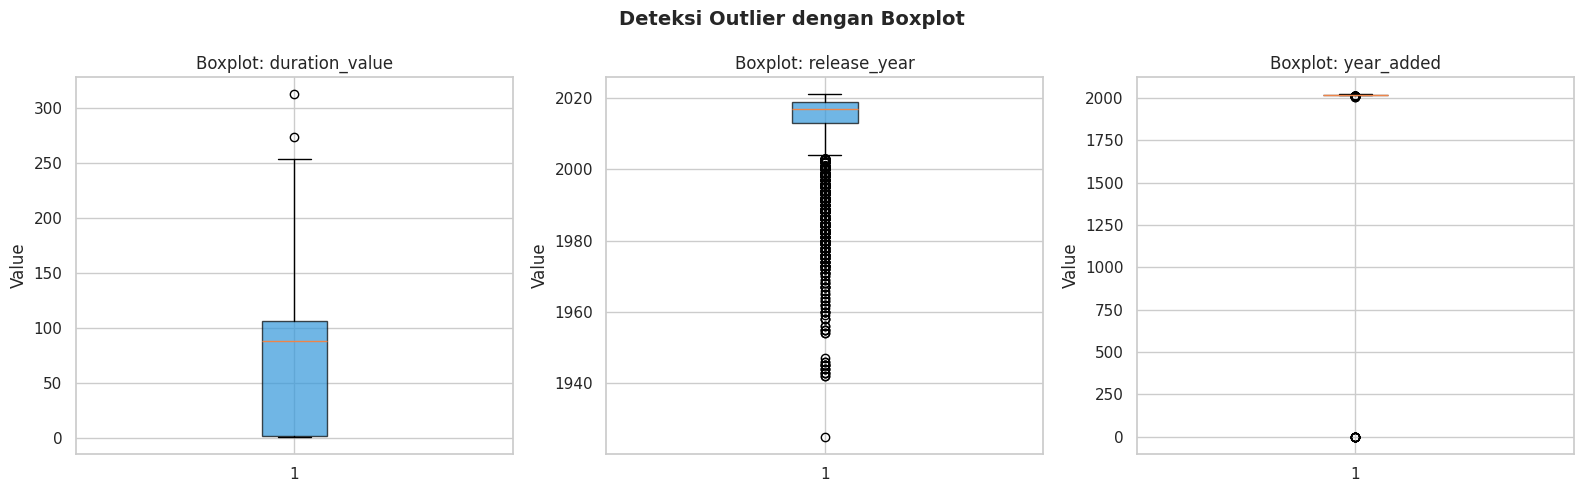


📊 Statistik IQR untuk Outlier:
duration_value: Q1=2.0, Q3=106.0, IQR=104.0, Batas=[-154.0, 262.0], Outlier=2 (0.02%)
release_year: Q1=2013.0, Q3=2019.0, IQR=6.0, Batas=[2004.0, 2028.0], Outlier=719 (8.17%)
year_added: Q1=2018.0, Q3=2020.0, IQR=2.0, Batas=[2015.0, 2023.0], Outlier=66 (0.75%)


In [14]:

numeric_cols = ['duration_value', 'release_year', 'year_added']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_feat[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('Value')
plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print('\n📊 Statistik IQR untuk Outlier:')
for col in numeric_cols:
    Q1 = df_feat[col].quantile(0.25)
    Q3 = df_feat[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = df_feat[(df_feat[col] < lower) | (df_feat[col] > upper)].shape[0]
    pct = round(n_outlier/len(df_feat)*100, 2)
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Batas=[{lower:.1f}, {upper:.1f}], Outlier={n_outlier} ({pct}%)')

In [15]:
def cap_outlier_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)

movie_mask = df_feat['type'] == 'Movie'
tv_mask = df_feat['type'] == 'TV Show'

df_feat.loc[movie_mask, 'duration_value'] = cap_outlier_iqr(df_feat.loc[movie_mask, 'duration_value'])
df_feat.loc[tv_mask, 'duration_value'] = cap_outlier_iqr(df_feat.loc[tv_mask, 'duration_value'])

print('✅ Outlier duration_value ditangani dengan IQR capping (Winsorizing)')
print(f'  Movie duration: {df_feat.loc[movie_mask, "duration_value"].describe()}')
print(f'  TV Show duration: {df_feat.loc[tv_mask, "duration_value"].describe()}')

✅ Outlier duration_value ditangani dengan IQR capping (Winsorizing)
  Movie duration: count    6128.000000
mean       99.578982
std        25.017308
min        46.500000
25%        87.000000
50%        98.000000
75%       114.000000
max       154.500000
Name: duration_value, dtype: float64
  TV Show duration: count    2676.000000
mean        1.549514
std         0.871499
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.500000
Name: duration_value, dtype: float64


## 1.6 Normalisasi / Standarisasi

In [16]:
# Pilih fitur untuk model
genre_cols = [c for c in df_feat.columns if c.startswith('genre_')]

feature_cols = [
    'duration_value', 'release_year', 'year_added',
    'rating_encoded', 'country_encoded'
] + genre_cols

X = df_feat[feature_cols].copy()
y = df_feat['target'].copy()

print(f'📊 Jumlah fitur: {X.shape[1]}')
print(f'📊 Jumlah sampel: {X.shape[0]}')
print(f'📊 Distribusi target: Movie={y.sum()} | TV Show={(y==0).sum()}')

# Standarisasi fitur numerik kontinu
scaler = StandardScaler()
cols_to_scale = ['duration_value', 'release_year', 'year_added']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print('\n✅ Standarisasi berhasil pada kolom:', cols_to_scale)
X[cols_to_scale].describe().round(3)

📊 Jumlah fitur: 20
📊 Jumlah sampel: 8804
📊 Distribusi target: Movie=6128 | TV Show=2676

✅ Standarisasi berhasil pada kolom: ['duration_value', 'release_year', 'year_added']


,duration_value,release_year,year_added
count,8804.000,8804.000,8804.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-1.384,-10.111,-29.647
25%,-1.364,-0.134,0.021
50%,0.367,0.320,0.036
75%,0.729,0.546,0.050
max,1.705,0.773,0.065


## 1.7 Visualisasi Data (EDA)

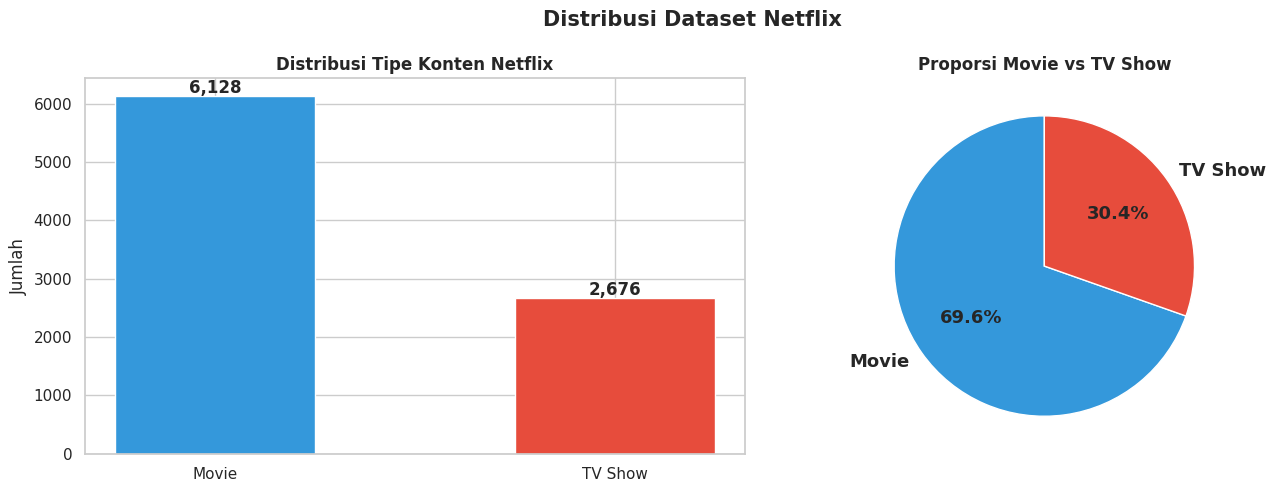

In [17]:
# ---- Plot 1: Distribusi Movie vs TV Show ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
type_counts = df_feat['type'].value_counts()
bars = axes[0].bar(type_counts.index, type_counts.values, color=['#3498db','#e74c3c'], width=0.5)
axes[0].set_title('Distribusi Tipe Konten Netflix', fontweight='bold')
axes[0].set_ylabel('Jumlah')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{bar.get_height():,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c'], startangle=90,
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Movie vs TV Show', fontweight='bold')

plt.suptitle('Distribusi Dataset Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

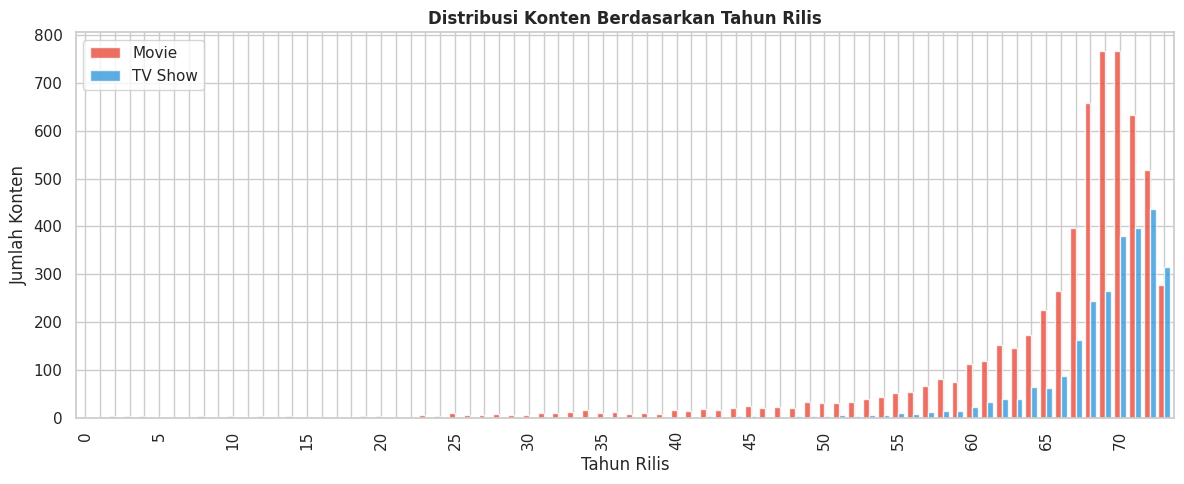

In [18]:
# ---- Plot 2: Distribusi Release Year ----
fig, ax = plt.subplots(figsize=(12, 5))
df_feat.groupby(['release_year', 'type']).size().unstack().plot(
    kind='bar', ax=ax, color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8
)
ax.set_title('Distribusi Konten Berdasarkan Tahun Rilis', fontweight='bold')
ax.set_xlabel('Tahun Rilis')
ax.set_ylabel('Jumlah Konten')
ax.legend(['Movie', 'TV Show'])
ax.set_xticklabels([str(int(x)) if i % 5 == 0 else '' for i, x in enumerate(ax.get_xticks())])
plt.tight_layout()
plt.show()

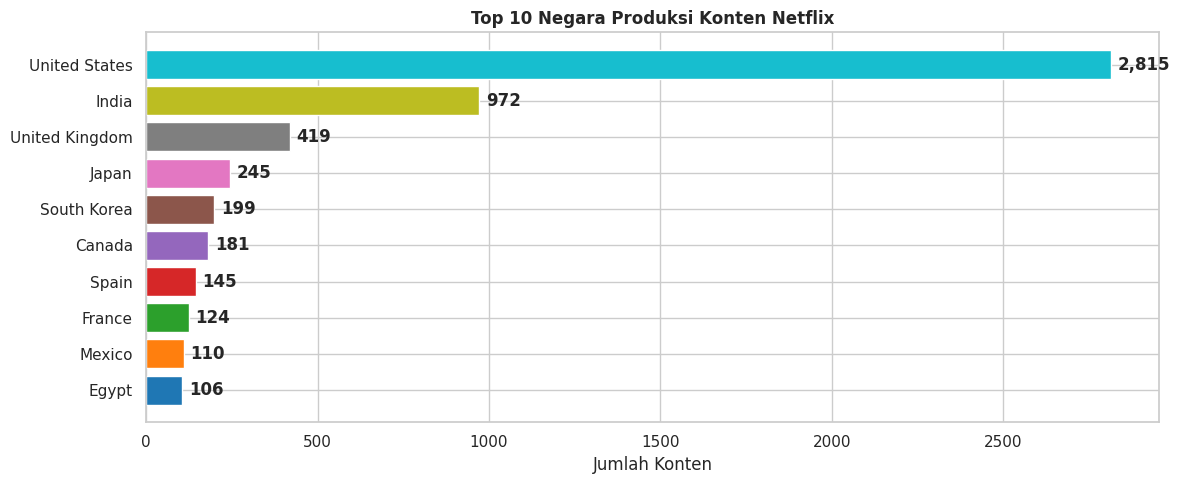

In [19]:
# ---- Plot 3: Top 10 Negara ----
fig, ax = plt.subplots(figsize=(12, 5))
top_countries = df_feat[df_feat['country'] != 'Unknown']['country'].value_counts().head(10)
colors = plt.cm.tab10(range(10))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors)
ax.set_title('Top 10 Negara Produksi Konten Netflix', fontweight='bold')
ax.set_xlabel('Jumlah Konten')
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

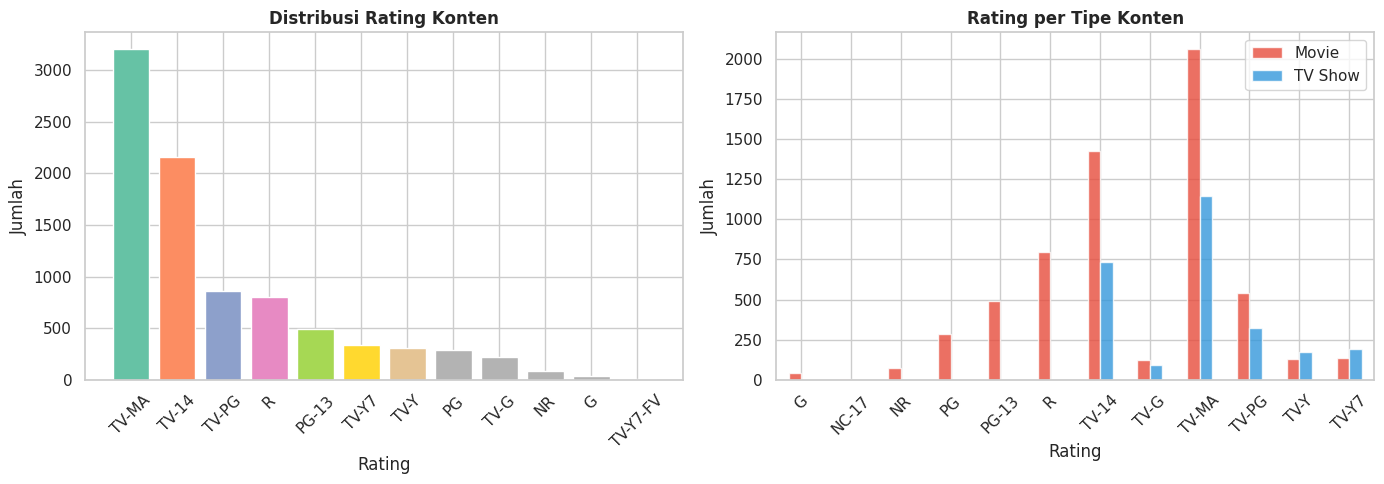

In [20]:
# ---- Plot 4: Distribusi Rating ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating keseluruhan
rating_counts = df_feat['rating'].value_counts().head(12)
axes[0].bar(rating_counts.index, rating_counts.values, color=plt.cm.Set2(range(12)))
axes[0].set_title('Distribusi Rating Konten', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

# Rating per tipe
rating_type = df_feat.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_type.head(12).plot(kind='bar', ax=axes[1], color=['#e74c3c','#3498db'], alpha=0.8)
axes[1].set_title('Rating per Tipe Konten', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Movie', 'TV Show'])

plt.tight_layout()
plt.show()

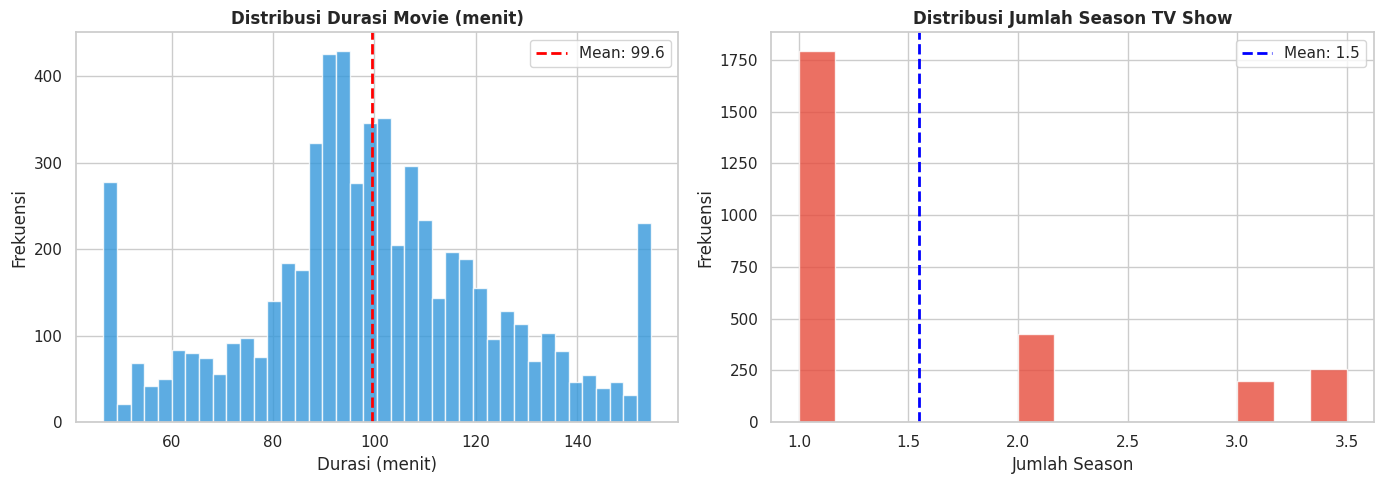

In [21]:
# ---- Plot 5: Histogram Durasi ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Durasi Movie
movie_dur = df_feat[df_feat['type']=='Movie']['duration_value']
axes[0].hist(movie_dur, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(movie_dur.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {movie_dur.mean():.1f}')
axes[0].set_title('Distribusi Durasi Movie (menit)', fontweight='bold')
axes[0].set_xlabel('Durasi (menit)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Durasi TV Show
tv_dur = df_feat[df_feat['type']=='TV Show']['duration_value']
axes[1].hist(tv_dur, bins=15, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].axvline(tv_dur.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: {tv_dur.mean():.1f}')
axes[1].set_title('Distribusi Jumlah Season TV Show', fontweight='bold')
axes[1].set_xlabel('Jumlah Season')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

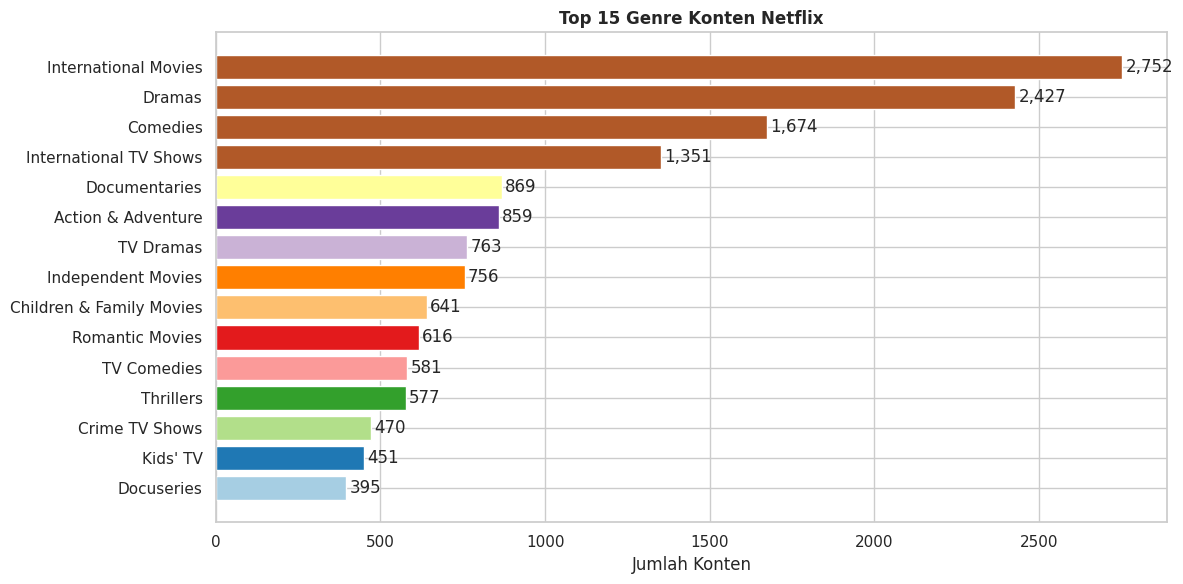

In [22]:
# ---- Plot 6: Top 10 Genre ----
fig, ax = plt.subplots(figsize=(12, 6))

genre_counts = df_feat['listed_in'].str.split(', ').explode().value_counts().head(15)
colors = plt.cm.Paired(range(15))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors)
ax.set_title('Top 15 Genre Konten Netflix', fontweight='bold')
ax.set_xlabel('Jumlah Konten')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center')
plt.tight_layout()
plt.show()

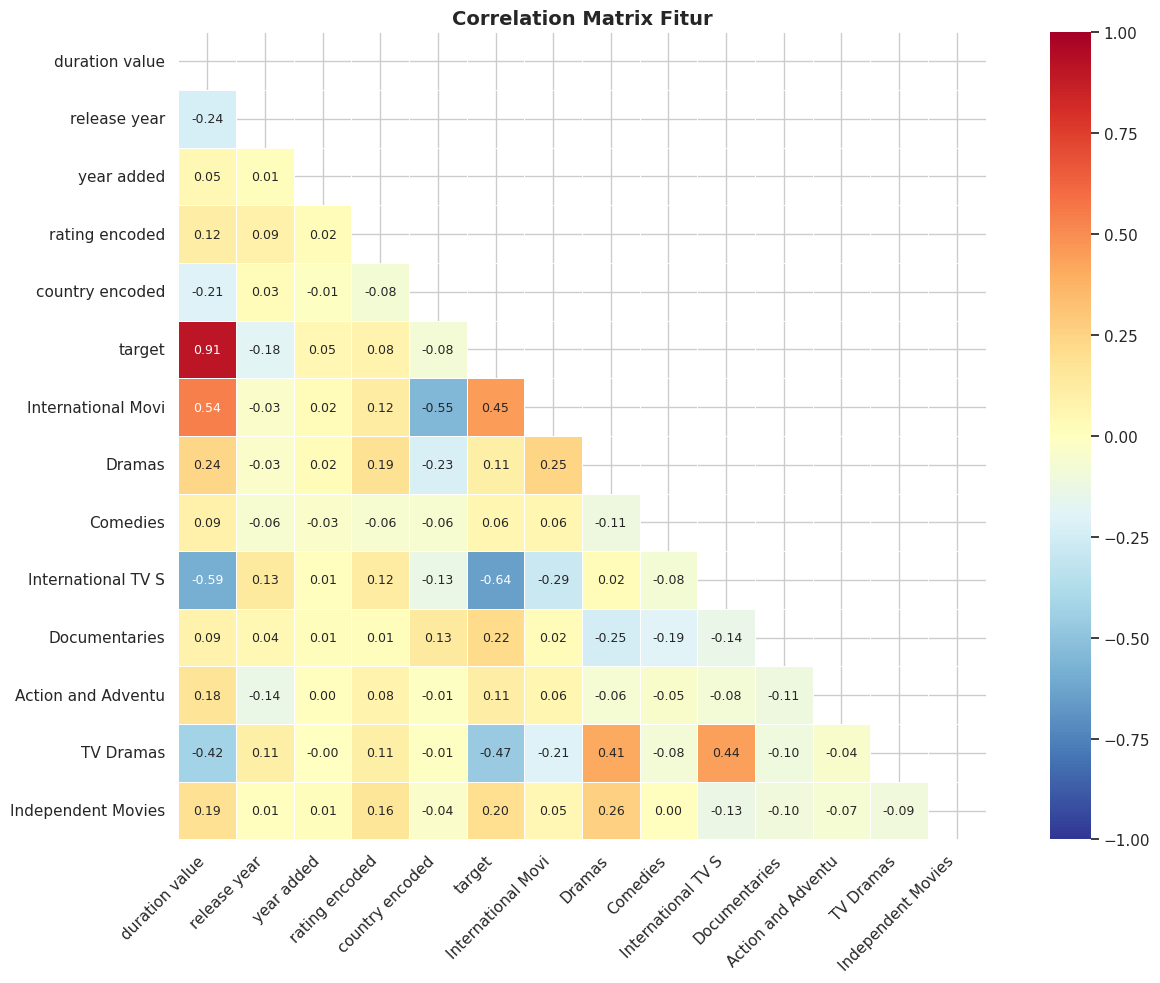

In [23]:
# ---- Plot 7: Correlation Matrix ----
corr_cols = ['duration_value', 'release_year', 'year_added', 'rating_encoded',
             'country_encoded', 'target'] + genre_cols[:8]

corr_data = df_feat[corr_cols].copy()
corr_data.columns = [c.replace('genre_', '').replace('_', ' ')[:18] for c in corr_data.columns]

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(
    corr_data.corr(), annot=True, fmt='.2f', mask=mask,
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix Fitur', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
# STEP 2: Training & Testing Model Supervised Learning
## 2.1 Splitting Data (80:20)

In [24]:
# Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data berhasil di-split!')
print(f'  Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Testing set   : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribusi kelas di training set:')
print(f'  Movie   : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'  TV Show : {(y_train==0).sum()} ({(1-y_train.mean())*100:.1f}%)')
print()
print('Distribusi kelas di testing set:')
print(f'  Movie   : {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'  TV Show : {(y_test==0).sum()} ({(1-y_test.mean())*100:.1f}%)')

✅ Data berhasil di-split!
  Training set  : 7043 sampel (80.0%)
  Testing set   : 1761 sampel (20.0%)

Distribusi kelas di training set:
  Movie   : 4902 (69.6%)
  TV Show : 2141 (30.4%)

Distribusi kelas di testing set:
  Movie   : 1226 (69.6%)
  TV Show : 535 (30.4%)


## 2.2 Model 1: Random Forest Classifier

In [25]:
# Inisialisasi dan training Random Forest
print('🌲 Training Random Forest Classifier...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('✅ Random Forest berhasil di-training!')

# Prediksi
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(f'  Akurasi pada training set: {accuracy_score(y_train, rf_model.predict(X_train))*100:.2f}%')
print(f'  Akurasi pada testing set : {accuracy_score(y_test, rf_pred)*100:.2f}%')

🌲 Training Random Forest Classifier...
✅ Random Forest berhasil di-training!
  Akurasi pada training set: 100.00%
  Akurasi pada testing set : 100.00%


## 2.3 Model 2: Logistic Regression

In [26]:
# Inisialisasi dan training Logistic Regression
print('📈 Training Logistic Regression...')

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)

lr_model.fit(X_train, y_train)
print('✅ Logistic Regression berhasil di-training!')

# Prediksi
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print(f'  Akurasi pada training set: {accuracy_score(y_train, lr_model.predict(X_train))*100:.2f}%')
print(f'  Akurasi pada testing set : {accuracy_score(y_test, lr_pred)*100:.2f}%')

📈 Training Logistic Regression...
✅ Logistic Regression berhasil di-training!
  Akurasi pada training set: 100.00%
  Akurasi pada testing set : 100.00%


---
# STEP 3: Evaluasi Model
## 3.1 Metrik Evaluasi

In [27]:
# Hitung semua metrik evaluasi
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

rf_metrics = evaluate_model('Random Forest', y_test, rf_pred)
lr_metrics = evaluate_model('Logistic Regression', y_test, lr_pred)

metrics_df = pd.DataFrame([rf_metrics, lr_metrics]).set_index('Model')
print('📊 Perbandingan Metrik Evaluasi:')
print((metrics_df * 100).round(2).to_string(), '%')

📊 Perbandingan Metrik Evaluasi:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Random Forest           100.0      100.0   100.0     100.0
Logistic Regression     100.0      100.0   100.0     100.0 %


In [28]:
# Classification Report lengkap
print('=' * 55)
print('  RANDOM FOREST — Classification Report')
print('=' * 55)
print(classification_report(y_test, rf_pred, target_names=['TV Show', 'Movie']))

print('=' * 55)
print('  LOGISTIC REGRESSION — Classification Report')
print('=' * 55)
print(classification_report(y_test, lr_pred, target_names=['TV Show', 'Movie']))

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       535
       Movie       1.00      1.00      1.00      1226

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761

  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       535
       Movie       1.00      1.00      1.00      1226

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



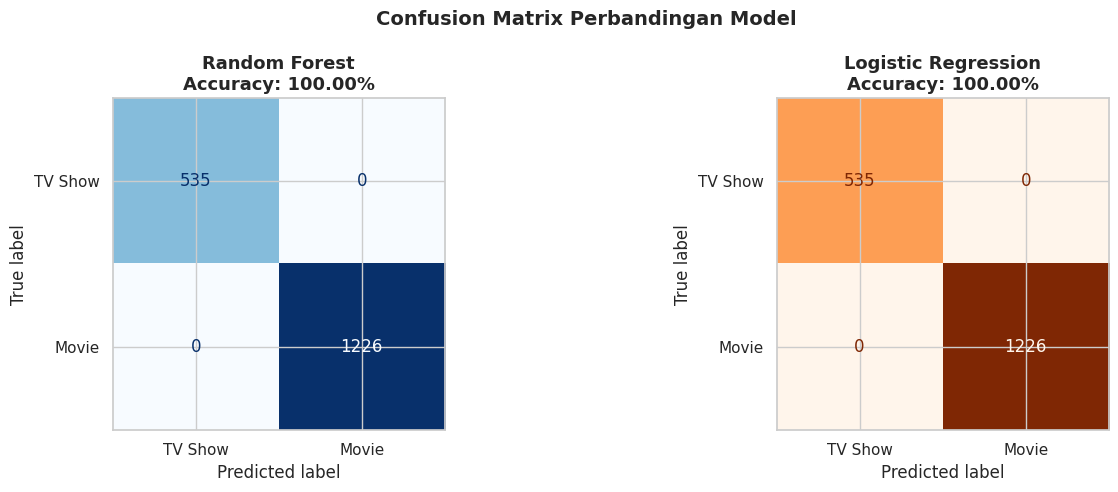

In [29]:
# ---- Confusion Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name, color in zip(
    axes, [rf_pred, lr_pred],
    ['Random Forest', 'Logistic Regression'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TV Show', 'Movie'])
    disp.plot(ax=ax, cmap=color, colorbar=False)
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=13)

plt.suptitle('Confusion Matrix Perbandingan Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

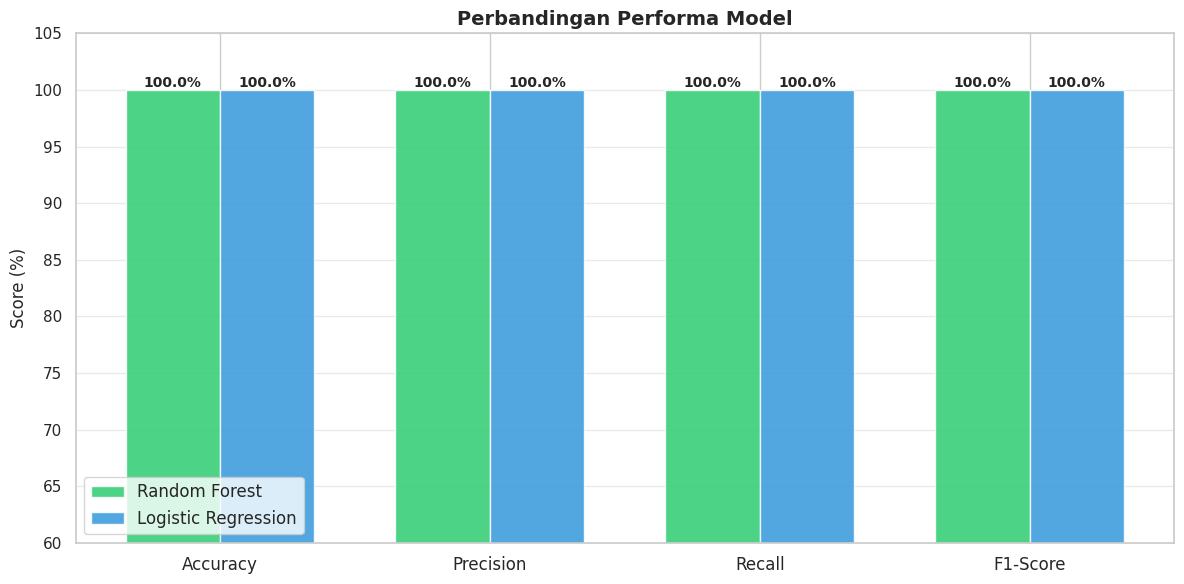

In [30]:
# ---- Bar Chart Perbandingan Metrik ----
fig, ax = plt.subplots(figsize=(12, 6))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_vals  = [rf_metrics[m] * 100 for m in metric_names]
lr_vals  = [lr_metrics[m] * 100 for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, lr_vals, width, label='Logistic Regression', color='#3498db', alpha=0.85)

ax.set_ylabel('Score (%)')
ax.set_title('Perbandingan Performa Model', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(60, 105)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

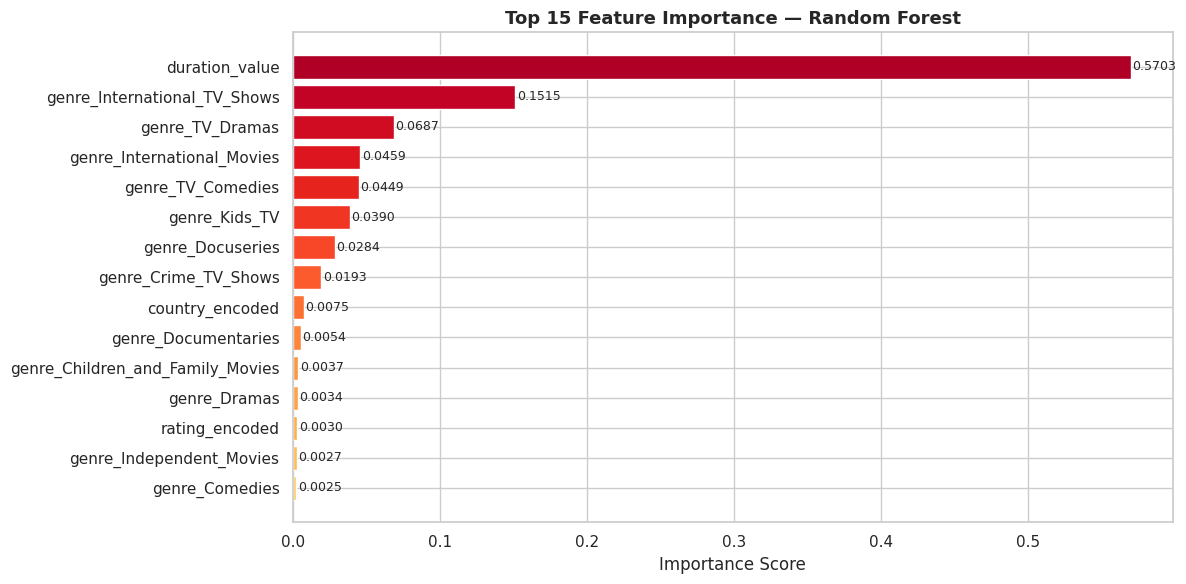

In [31]:
# ---- Feature Importance (Random Forest) ----
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp_df)))
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color=colors)
ax.set_title('Top 15 Feature Importance — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3.2 Kesimpulan & Pemilihan Model Terbaik

In [32]:
# Kesimpulan
best = metrics_df['Accuracy'].idxmax()
print('=' * 60)
print('           RINGKASAN EVALUASI MODEL')
print('=' * 60)
print((metrics_df * 100).round(2).to_string())
print()
print(f'🏆 Model Terbaik  : {best}')
print(f'   Accuracy       : {metrics_df.loc[best, "Accuracy"]*100:.2f}%')
print(f'   F1-Score       : {metrics_df.loc[best, "F1-Score"]*100:.2f}%')
print()
print('→ Model ini akan di-deploy ke website online.')
print('=' * 60)

           RINGKASAN EVALUASI MODEL
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Random Forest           100.0      100.0   100.0     100.0
Logistic Regression     100.0      100.0   100.0     100.0

🏆 Model Terbaik  : Random Forest
   Accuracy       : 100.00%
   F1-Score       : 100.00%

→ Model ini akan di-deploy ke website online.


## 3.3 Simpan Model untuk Deployment

In [33]:
import pickle, json

# Simpan model terbaik (Random Forest)
with open('netflix_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Simpan scaler
with open('netflix_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Simpan metadata model
model_info = {
    'model_name': 'Random Forest Classifier',
    'accuracy': round(float(metrics_df.loc['Random Forest', 'Accuracy']), 4),
    'precision': round(float(metrics_df.loc['Random Forest', 'Precision']), 4),
    'recall': round(float(metrics_df.loc['Random Forest', 'Recall']), 4),
    'f1_score': round(float(metrics_df.loc['Random Forest', 'F1-Score']), 4),
    'features': feature_cols,
    'cols_to_scale': cols_to_scale,
    'target': {'0': 'TV Show', '1': 'Movie'}
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print('✅ Model berhasil disimpan:')
print('   - netflix_model.pkl')
print('   - netflix_scaler.pkl')
print('   - model_info.json')
print()
print('📌 File ini akan digunakan untuk deployment di Step 4!')

✅ Model berhasil disimpan:
   - netflix_model.pkl
   - netflix_scaler.pkl
   - model_info.json

📌 File ini akan digunakan untuk deployment di Step 4!
